In [25]:
#!pip install langgraph

In [26]:
#!pip install langchain

In [27]:
#!pip install langchain_openai

In [5]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [6]:
from getpass import getpass
OPENAI_API_KEY=getpass("Enter OPENAI API key")

Enter OPENAI API key··········


In [7]:
import os
os.environ["OPENAI_API_KEY"]=OPENAI_API_KEY

In [8]:
model=ChatOpenAI(model="gpt-4o-mini")

In [10]:
# Creating state

In [11]:
class BlogState(TypedDict):
  title:str
  outline:str
  content:str

In [12]:
graph=StateGraph(BlogState)

In [13]:
#Nodes

In [14]:
def create_outline(state: BlogState)->BlogState:

  # Fetch title
  title=state['title']
  # Call llm
  prompt=f"Generate a detailed outline for a blog on the topic - {title}"
  outline=model.invoke(prompt).content
  # update state
  state['outline']=outline
  return state

In [15]:
def create_blog(state: BlogState)->BlogState:
  title=state['title']
  outline=state['outline']
  prompt=f"Write a detailed blog on title {title} using the following outline - {outline}"
  content=model.invoke(prompt).content
  state['content']=content
  return state

In [16]:
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)

In [17]:
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

In [18]:
workFlow=graph.compile()

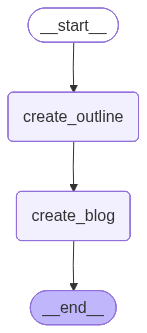

In [19]:
workFlow

In [21]:
initial_state={'title':"Rise of AI in India"}
final_state=workFlow.invoke(initial_state)

In [22]:
final_state

{'title': 'Rise of AI in India',
 'outline': "# Outline for Blog: The Rise of AI in India\n\n## Introduction\n- Define Artificial Intelligence (AI) and its relevance in today's technological landscape.\n- Briefly discuss the global influence of AI and its growing importance in various sectors.\n- Introduce the focus on India’s emergence as a key player in the AI sector.\n\n## I. Historical Context of AI in India\n### A. Early Developments\n- Overview of the inception of AI in India during the 1980s and 1990s.\n- Notable early projects and research initiatives.\n\n### B. Government Initiatives\n- Highlight key policies and programs initiated in the early 2000s to promote AI research.\n- Discuss the establishment of institutions focused on AI and computer science.\n\n## II. Current Landscape of AI in India\n### A. Government Support and Policies\n- Discuss the National AI Strategy launched by NITI Aayog.\n- Explore funding, incentives, and strategies for AI development at the state and n

In [23]:
final_state['outline']

"# Outline for Blog: The Rise of AI in India\n\n## Introduction\n- Define Artificial Intelligence (AI) and its relevance in today's technological landscape.\n- Briefly discuss the global influence of AI and its growing importance in various sectors.\n- Introduce the focus on India’s emergence as a key player in the AI sector.\n\n## I. Historical Context of AI in India\n### A. Early Developments\n- Overview of the inception of AI in India during the 1980s and 1990s.\n- Notable early projects and research initiatives.\n\n### B. Government Initiatives\n- Highlight key policies and programs initiated in the early 2000s to promote AI research.\n- Discuss the establishment of institutions focused on AI and computer science.\n\n## II. Current Landscape of AI in India\n### A. Government Support and Policies\n- Discuss the National AI Strategy launched by NITI Aayog.\n- Explore funding, incentives, and strategies for AI development at the state and national levels.\n\n### B. Key Sectors Embraci

In [24]:
final_state['content']

'# The Rise of AI in India\n\n## Introduction\n\nArtificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, particularly computer systems. It encompasses capabilities such as learning, reasoning, problem-solving, perception, language understanding, and data analysis. In today\'s technological landscape, AI is not merely a buzzword; it\'s a transformative force driving innovation across various sectors, from healthcare to finance to agriculture. Globally, AI technologies are reshaping industries and redefining how businesses operate, but India is emerging as a notable player in this field. As one of the largest tech ecosystems in the world, India is witnessing a robust rise in AI initiatives, showcasing its potential to innovate and influence the global AI landscape.\n\n## I. Historical Context of AI in India\n\n### A. Early Developments\n\nAI in India can trace its roots back to the 1980s and 1990s, a period characterized by the nascent phases of